## Анализ результатов экспериментов

Сравнение трёх алгоритмов поиска пути на графах с распределением Кокса:
- **Dijkstra** — планирует путь по текущим (выборочным) весам, затем проходит с учётом динамики весов
- **ExpectedDijkstra** — планирует по математическим ожиданиям весов, затем проходит с учётом динамики
- **AdaptiveDijkstra** — перепланирует путь после каждого ребра с обновлением весов

In [1]:
import sys
sys.path.append('..')
from experiments.visualization import *
from experiments.runner import run_experiments
from experiments.config import EXPERIMENT_CONFIG

In [2]:
# Запуск экспериментов (может занять время)
results_path = run_experiments(EXPERIMENT_CONFIG)

# Или загрузка уже существующих результатов:
# results_path = "../results/experiment_YYYYMMDD_HHMMSS.csv"
df = load_results(results_path)

Результаты сохранены в results\experiment_20260514_074105.csv


In [3]:
# Фильтруем inf (нет пути) и смотрим на данные
df = df[df['time'] != float('inf')]
print(f"Записей после фильтрации: {len(df)}")
df.head()

Записей после фильтрации: 1200


,graph_size,topology,distribution,run,source,target,algorithm,time,path_length,path,path_differs_from_dijkstra
0,10,random,static_exp,0,3,4,dijkstra,1.975163,3,3-5-4,False
1,10,random,static_exp,0,3,4,adaptive_dijkstra,2.576722,3,3-5-4,False
2,10,random,static_exp,0,3,4,expected_dijkstra,0.595134,3,3-2-4,True
3,10,random,static_exp,0,3,4,astar,4.683525,3,3-5-4,False
4,10,random,static_exp,1,9,4,dijkstra,5.594999,6,9-6-0-5-1-4,False


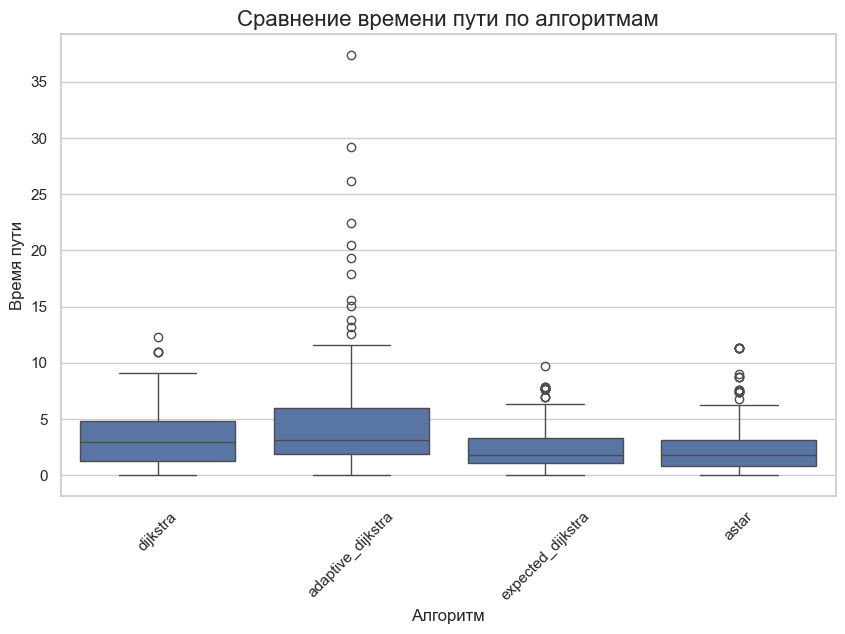

In [4]:
# Распределение времени пути по алгоритмам
plot_time_by_algorithm(df)

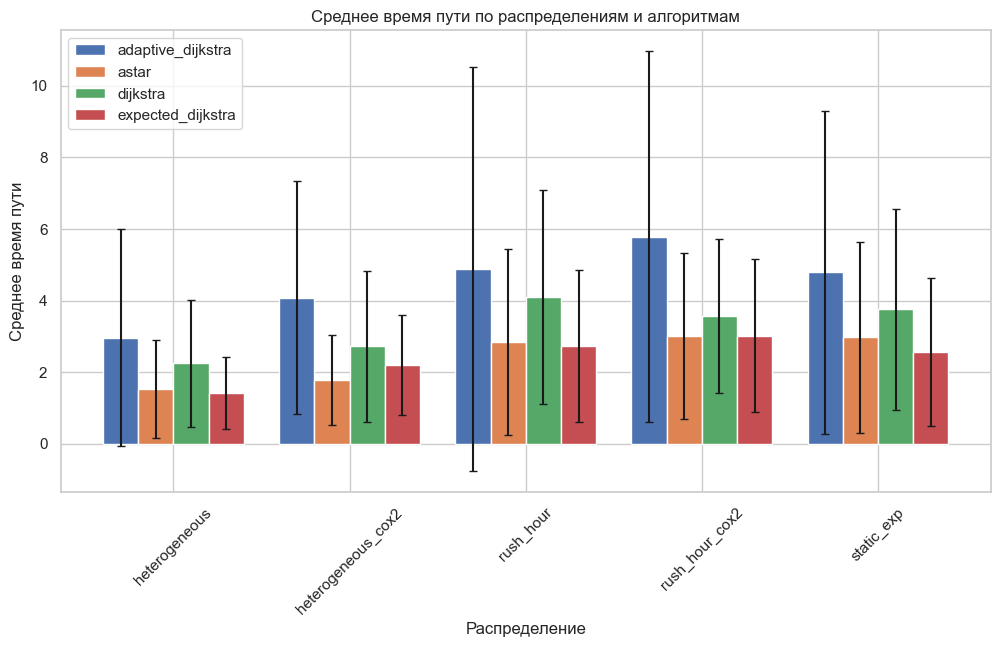

In [5]:
# Среднее время пути по распределениям и алгоритмам
plot_time_by_distribution(df)

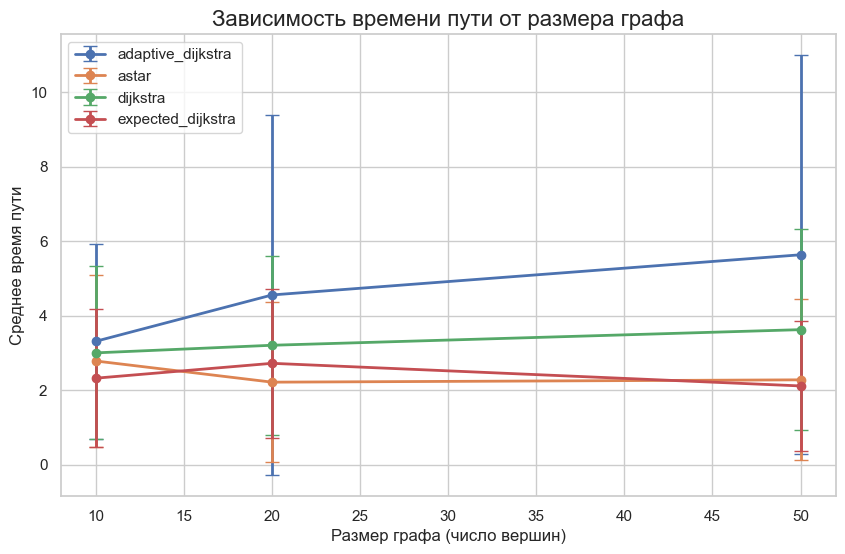

In [6]:
# Зависимость времени пути от размера графа
plot_time_vs_graph_size(df)

### Попарное сравнение алгоритмов

Для каждого запуска определяем алгоритм с минимальным временем прохождения.
ExpectedDijkstra побеждает чаще, т.к. планирование по мат. ожиданию
выбирает путь, оптимальный в среднем, а не под одну реализацию.

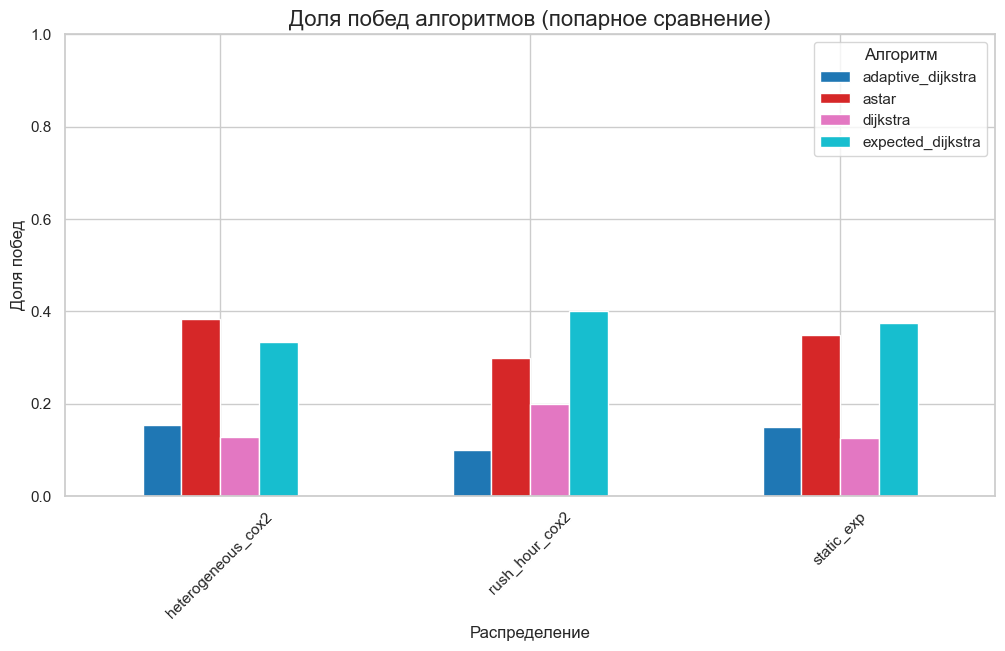

In [7]:
from experiments.visualization import *

plot_head_to_head(df)

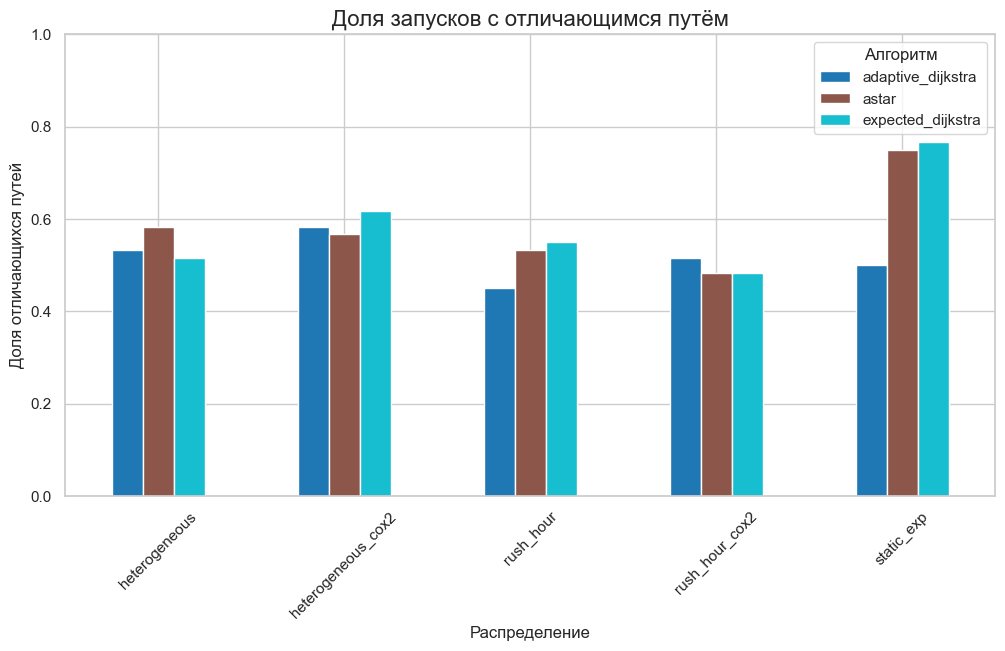

In [8]:
# Доля запусков, в которых путь отличается от Dijkstra
plot_path_divergence(df)

In [9]:
# Сводная таблица средних времён
summary = df.groupby(['distribution', 'algorithm'])['time'].agg(['mean', 'std', 'count']).round(3)
summary

mean    std  count
distribution       algorithm                             
heterogeneous      adaptive_dijkstra  2.967  3.038     60
                   astar              1.531  1.377     60
                   dijkstra           2.251  1.773     60
                   expected_dijkstra  1.417  1.016     60
heterogeneous_cox2 adaptive_dijkstra  4.085  3.248     60
                   astar              1.775  1.256     60
                   dijkstra           2.719  2.102     60
                   expected_dijkstra  2.200  1.391     60
rush_hour          adaptive_dijkstra  4.885  5.651     60
                   astar              2.841  2.591     60
                   dijkstra           4.103  2.980     60
                   expected_dijkstra  2.733  2.131     60
rush_hour_cox2     adaptive_dijkstra  5.785  5.181     60
                   astar              3.007  2.318     60
                   dijkstra           3.566  2.142     60
                   expected_dijkstra  3.024  2.146     60
static_exp         adaptive_dijkstra  4.789  4.519     60
                   astar              2.978  2.671     60
                   dijkstra           3.754  2.808     60
                   expected_dijkstra  2.561  2.073     60